In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling  import SMOTE

SEED = 42
np.random.seed(SEED)

print(" Libraries imported successfully")

 Libraries imported successfully


In [2]:
RAW_PATH = "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(RAW_PATH)

print(f"Shape       : {df.shape}")
print(f"Columns     : {list(df.columns)}")
print(f"\nFirst 3 rows:")
df.head(3)

Shape       : (7043, 21)
Columns     : ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First 3 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [3]:
print("── Data Types ───────────────────────────────")
print(df.dtypes)

print("\n── Missing Values ───────────────────────────")
print(df.isnull().sum())

print("\n── Target Distribution ──────────────────────")
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True).round(3))

── Data Types ───────────────────────────────
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

── Missing Values ───────────────────────────
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV        

In [4]:
# TotalCharges is stored as string — some rows contain whitespace " "
# pd.to_numeric with errors='coerce' converts them to NaN safely

print("TotalCharges dtype BEFORE:", df["TotalCharges"].dtype)
print("Sample values:", df["TotalCharges"].unique()[:8])

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("\nTotalCharges dtype AFTER :", df["TotalCharges"].dtype)
print("NaN count after conversion:", df["TotalCharges"].isnull().sum())

# These NaN rows are customers with 0 tenure — safe to drop
df.dropna(subset=["TotalCharges"], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"\nRows after dropping NaN   : {len(df)}")

TotalCharges dtype BEFORE: str
Sample values: <StringArray>
['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5', '1949.4', '301.9']
Length: 8, dtype: str

TotalCharges dtype AFTER : float64
NaN count after conversion: 11

Rows after dropping NaN   : 7032


In [5]:
# customerID is a unique identifier — no predictive value
df.drop(columns=["customerID"], inplace=True)

print(f"Columns after dropping customerID: {df.shape[1]}")
print(list(df.columns))

Columns after dropping customerID: 20
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [6]:
# Columns with exactly 2 unique values → LabelEncoder (0 / 1)
binary_cols = [
    "gender", "Partner", "Dependents",
    "PhoneService", "PaperlessBilling", "Churn"
]

le = LabelEncoder()

for col in binary_cols:
    df[col] = le.fit_transform(df[col])
    unique_vals = df[col].unique()
    print(f"  {col:20s} → {unique_vals}")

print(f"\n {len(binary_cols)} binary columns encoded")
print(df[binary_cols].head(3))

  gender               → [0 1]
  Partner              → [1 0]
  Dependents           → [0 1]
  PhoneService         → [0 1]
  PaperlessBilling     → [1 0]
  Churn                → [0 1]

 6 binary columns encoded
   gender  Partner  Dependents  PhoneService  PaperlessBilling  Churn
0       0        1           0             0                 1      0
1       1        0           0             1                 0      0
2       1        0           0             1                 1      1


In [7]:
# Columns with 3+ categories → one-hot encoding (creates dummy variables)
multi_cat_cols = [
    "MultipleLines", "InternetService", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"
]

print("Shape BEFORE one-hot encoding:", df.shape)

df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=False)

# Convert bool columns to int (some pandas versions produce bool dummies)
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

print("Shape AFTER  one-hot encoding:", df.shape)
print(f"\nAll columns ({df.shape[1]}):")
for col in df.columns:
    print(f"  {col}")

Shape BEFORE one-hot encoding: (7032, 20)
Shape AFTER  one-hot encoding: (7032, 41)

All columns (41):
  gender
  SeniorCitizen
  Partner
  Dependents
  tenure
  PhoneService
  PaperlessBilling
  MonthlyCharges
  TotalCharges
  Churn
  MultipleLines_No
  MultipleLines_No phone service
  MultipleLines_Yes
  InternetService_DSL
  InternetService_Fiber optic
  InternetService_No
  OnlineSecurity_No
  OnlineSecurity_No internet service
  OnlineSecurity_Yes
  OnlineBackup_No
  OnlineBackup_No internet service
  OnlineBackup_Yes
  DeviceProtection_No
  DeviceProtection_No internet service
  DeviceProtection_Yes
  TechSupport_No
  TechSupport_No internet service
  TechSupport_Yes
  StreamingTV_No
  StreamingTV_No internet service
  StreamingTV_Yes
  StreamingMovies_No
  StreamingMovies_No internet service
  StreamingMovies_Yes
  Contract_Month-to-month
  Contract_One year
  Contract_Two year
  PaymentMethod_Bank transfer (automatic)
  PaymentMethod_Credit card (automatic)
  PaymentMethod_Elec

In [9]:
# X = all feature columns
# y = Churn column (target)

TARGET = "Churn"

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"Feature matrix X : {X.shape}")
print(f"Target vector  y : {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(y.value_counts(normalize=True).round(3))

# Save feature names NOW — before any numpy conversion strips them
# This is critical for the feature importance plot in notebook 03
feature_names = X.columns.tolist()
print(f"\nFeature names saved: {len(feature_names)} features")

Feature matrix X : (7032, 40)
Target vector  y : (7032,)

Target distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64
Churn
0    0.734
1    0.266
Name: proportion, dtype: float64

Feature names saved: 40 features


In [10]:
# stratify=y ensures both splits maintain the same churn ratio (~27%)
# This prevents one split from accidentally having all the churners

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = SEED,
    stratify     = y       # ← critical for imbalanced data
)

print("Split complete:")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"\nChurn rate in train : {y_train.mean()*100:.1f}%  (should be ~26–27%)")
print(f"Churn rate in test  : {y_test.mean()*100:.1f}%  (should be ~26–27%)")

Split complete:
  X_train : (5625, 40)
  X_test  : (1407, 40)

Churn rate in train : 26.6%  (should be ~26–27%)
Churn rate in test  : 26.6%  (should be ~26–27%)


In [11]:
# StandardScaler: mean=0, std=1 for each feature
# WHY: Logistic Regression and distance-based models are sensitive to scale
#      Random Forest does NOT need scaling but it doesn't hurt
#
# RULE: fit ONLY on training data → transform both train and test
#       Fitting on test data = data leakage

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)        # transform only on test

print("Scaling complete:")
print(f"  X_train_scaled : {X_train_scaled.shape}")
print(f"  X_test_scaled  : {X_test_scaled.shape}")
print(f"\n  Train mean (should be ~0.0): {X_train_scaled.mean():.4f}")
print(f"  Train std  (should be ~1.0): {X_train_scaled.std():.4f}")
print(f"\n  Test  mean (will not be 0 exactly): {X_test_scaled.mean():.4f}")

Scaling complete:
  X_train_scaled : (5625, 40)
  X_test_scaled  : (1407, 40)

  Train mean (should be ~0.0): -0.0000
  Train std  (should be ~1.0): 1.0000

  Test  mean (will not be 0 exactly): -0.0032


In [12]:
# Problem: 73% No Churn vs 27% Churn → model will predict No Churn for everything
# SMOTE: Synthetic Minority Oversampling Technique
#        Creates synthetic churn samples by interpolating between real ones
#
# CRITICAL RULE: Apply SMOTE ONLY to training data
#                NEVER to test data — that would leak and fake the results

print("Before SMOTE:")
print(f"  Churn=0 : {(y_train == 0).sum():,}")
print(f"  Churn=1 : {(y_train == 1).sum():,}")
print(f"  Ratio   : {y_train.mean()*100:.1f}% churners")

smote = SMOTE(random_state=SEED)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("\nAfter SMOTE:")
print(f"  Churn=0 : {(y_train_bal == 0).sum():,}")
print(f"  Churn=1 : {(y_train_bal == 1).sum():,}")
print(f"  Ratio   : {y_train_bal.mean()*100:.1f}% churners  (should be 50%)")
print(f"\n  New training size: {len(X_train_bal):,} rows")

Before SMOTE:
  Churn=0 : 4,130
  Churn=1 : 1,495
  Ratio   : 26.6% churners

After SMOTE:
  Churn=0 : 4,130
  Churn=1 : 4,130
  Ratio   : 50.0% churners  (should be 50%)

  New training size: 8,260 rows


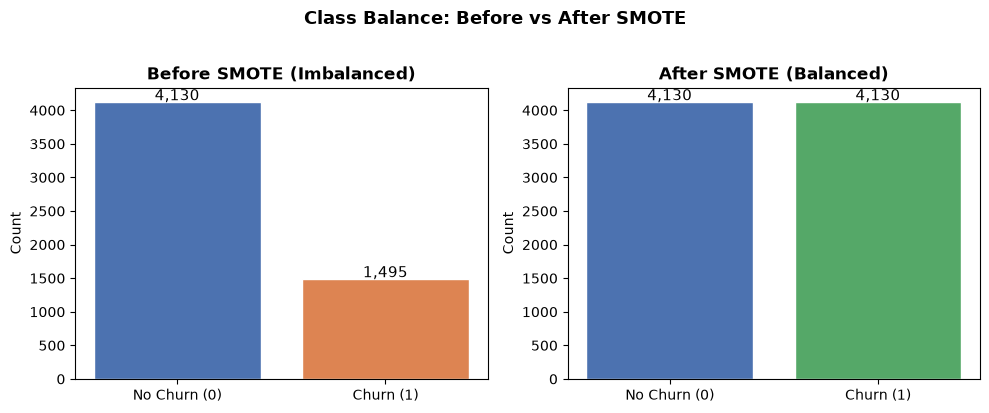

 Saved: images/smote_balance.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before SMOTE
axes[0].bar(["No Churn (0)", "Churn (1)"],
            [( y_train == 0).sum(), (y_train == 1).sum()],
            color=["#4C72B0", "#DD8452"], edgecolor="white")
axes[0].set_title("Before SMOTE (Imbalanced)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Count")
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20,
                 f"{int(bar.get_height()):,}",
                 ha="center", fontsize=11)

# After SMOTE
axes[1].bar(["No Churn (0)", "Churn (1)"],
            [(y_train_bal == 0).sum(), (y_train_bal == 1).sum()],
            color=["#4C72B0", "#55A868"], edgecolor="white")
axes[1].set_title("After SMOTE (Balanced)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Count")
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20,
                 f"{int(bar.get_height()):,}",
                 ha="center", fontsize=11)

plt.suptitle("Class Balance: Before vs After SMOTE", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()

os.makedirs("../images", exist_ok=True)
plt.savefig("../images/smote_balance.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Saved: images/smote_balance.png")

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# This is the KEY step that makes notebook 03 fully independent.
# Every array produced here is saved to CSV so notebook 03 can
# load from disk without depending on this kernel's memory.
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs("../data/processed", exist_ok=True)

# 1. SMOTE-balanced training data (for model training in notebook 03)
pd.DataFrame(X_train_bal).to_csv(
    "../data/processed/X_train_balanced.csv", index=False)

pd.DataFrame(y_train_bal, columns=["Churn"]).to_csv(
    "../data/processed/y_train_balanced.csv", index=False)

# 2. Test data (for evaluation — never touched by SMOTE)
pd.DataFrame(X_test_scaled).to_csv(
    "../data/processed/X_test.csv", index=False)

pd.DataFrame(y_test.values, columns=["Churn"]).to_csv(
    "../data/processed/y_test.csv", index=False)

# 3. Feature names — MUST be saved BEFORE scaling strips column names
#    Used in notebook 03 for the feature importance plot
pd.DataFrame(feature_names, columns=["feature"]).to_csv(
    "../data/processed/feature_names.csv", index=False)

# 4. Full cleaned dataset — used in notebook 04 to build the Power BI export
df.to_csv("../data/processed/cleaned_data.csv", index=False)

# ─────────────────────────────────────────────────────────────────────────────
# Verify everything was saved
# ─────────────────────────────────────────────────────────────────────────────
saved_files = {
    "X_train_balanced.csv" : "../data/processed/X_train_balanced.csv",
    "y_train_balanced.csv" : "../data/processed/y_train_balanced.csv",
    "X_test.csv"           : "../data/processed/X_test.csv",
    "y_test.csv"           : "../data/processed/y_test.csv",
    "feature_names.csv"    : "../data/processed/feature_names.csv",
    "cleaned_data.csv"     : "../data/processed/cleaned_data.csv",
}

print("── Files Saved ──────────────────────────────────────────────")
for name, path in saved_files.items():
    size = os.path.getsize(path) / 1024
    rows = pd.read_csv(path).shape[0]
    print(f"   {name:30s} {rows:>6,} rows  {size:>7.1f} KB")

print("\n Preprocessing complete.")
print("   You can now open 03_model_building.ipynb independently.")

── Files Saved ──────────────────────────────────────────────
   X_train_balanced.csv            8,260 rows   6297.5 KB
   y_train_balanced.csv            8,260 rows     24.2 KB
   X_test.csv                      1,407 rows   1072.7 KB
   y_test.csv                      1,407 rows      4.1 KB
   feature_names.csv                  40 rows      0.9 KB
   cleaned_data.csv                7,032 rows    635.0 KB

 Preprocessing complete.
   You can now open 03_model_building.ipynb independently.
